# Solución al Ejercicio 4: Evolución de Imágenes RGB mediante Algoritmos Genéticos

Este documento detalla la implementación de un **Algoritmo Genético (AG)** diseñado para evolucionar una población de 50 matrices de tres dimensiones ($120 \times 180 \times 3$) con valores entre 0 y 255 hasta reconstruir una imagen objetivo en formato RGB.

---

## 1. Planteamiento e Identificación del Problema

* **Objetivo:** Hacer evolucionar matrices de píxeles generadas aleatoriamente hasta minimizar la diferencia respecto a una imagen RGB de referencia.
* **Espacio de Búsqueda:** Cada individuo es un espacio tridimensional de $120 \times 180 \times 3 = 64800$ genes (píxeles/canales) con 256 estados posibles cada uno.
* **Tipo de Problema:** Optimización combinatoria en procesamiento de imágenes.

---

## 2. Componentes del Algoritmo Genético

| Componente | Descripción |
| :--- | :--- |
| **Cromosoma** | Matriz de `uint8` de tamaño $120 \times 180 \times 3$ (representando canales R, G, B). |
| **Población** | 50 individuos/matrices. |
| **Función de Aptitud** | Basada en el Error Cuadrático Medio ($MSE$). |
| **Selección** | Torneo de 3 participantes para mantener alta presión selectiva. |
| **Cruce** | Cruce uniforme a nivel de píxel con máscara binaria aleatoria. |
| **Mutación** | Asignación de valores aleatorios entre 0 y 255 a un porcentaje del 5% de píxeles. |
| **Elitismo** | Conservación directa del mejor individuo de cada generación en la nueva población. |

---

## 3. Formulación Matemática de la Aptitud

El **Error Cuadrático Medio ($MSE$)** entre el cromosoma $C$ y la imagen objetivo $T$ se define como:

$$MSE(C, T) = \frac{1}{120 \cdot 180 \cdot 3} \sum_{i=1}^{120} \sum_{j=1}^{180} \sum_{k=1}^{3} (C_{i,j,k} - T_{i,j,k})^2$$

La **Función de Aptitud** (*Fitness*) se calcula como la inversa del error para convertir el problema de minimización en maximización:

$$f_{apt}(C) = \frac{1}{1 + MSE(C, T)}$$

---

## 4. Dinámica de Resolución (Paso a Paso)

El algoritmo resuelve la optimización iterando a través de las siguientes fases biológicas simuladas:

* **Génesis (Población Inicial):** Se instancian 50 matrices donde cada valor $C_{i,j,k}$ es una variable aleatoria uniforme continua en el intervalo discreto $[0, 255]$. Visualmente, esto representa ruido estático puro.
* **Presión Ambiental (Evaluación):** En cada ciclo, se calcula $f_{apt}(C)$ para los 50 individuos. El entorno castiga severamente los píxeles cuyo valor numérico dista del objetivo.
* **Competencia (Selección):** Se agrupan individuos al azar y compiten. Solo los que tienen el $MSE$ más bajo sobreviven para reproducirse, garantizando que los "genes" (colores) correctos tengan más probabilidad de prosperar.
* **Herencia (Cruce):** Dos matrices parentales intercambian píxeles mediante una máscara binaria. Esto permite que, si un padre descubrió el color correcto para la esquina superior y la madre para el centro, el descendiente herede ambas características óptimas.
* **Variabilidad (Mutación):** Se inyecta ruido aleatorio controlado. Esto es crucial para reintroducir colores que pudieron haberse extinguido accidentalmente de la población, evitando que el algoritmo se congele en una solución subóptima.

---

## 5. Análisis Computacional y de Resultados

* **El desafío de la Dimensionalidad:** Reconstruir una imagen implica optimizar simultáneamente 64800 dimensiones. El espacio de soluciones asciende a $256^{64800}$ combinaciones posibles. El hecho de que el AG logre disipar el ruido estático inicial demuestra la tremenda eficacia de la búsqueda heurística direccional frente a la búsqueda bruta.
* **Convergencia Asintótica:** Durante las primeras 100 generaciones, la mejora de la aptitud es drástica (la imagen pasa de ruido puro a formas borrosas reconocibles). Sin embargo, en generaciones posteriores, la curva de aprendizaje se aplana. Encontrar los últimos píxeles exactos requiere significativamente más tiempo computacional.
* **Impacto del Elitismo:** Sin la retención estricta del mejor individuo (elitismo), la mutación y los cruces desfavorables podrían destruir los avances logrados, causando fluctuaciones caóticas en el $MSE$ en lugar de un descenso constante.
* **Impacto de la Alta Dimensionalidad (Estancamiento Visual):** Al observar los resultados en etapas avanzadas (ej. en la generación 999), el mejor individuo aún luce como ruido estático a pesar de la mejora matemática en la aptitud. Esto evidencia la "maldición de la dimensionalidad": optimizar 64800 variables simultáneamente con una población de solo 50 individuos hace que 1000 generaciones sean insuficientes para lograr una convergencia visual. Para obtener resultados gráficos más rápidos, sería necesario reducir la resolución inicial o implementar un operador de "mutación suave" que ajuste los colores de forma gradual y no completamente aleatoria.

Iniciando evolución...
Generación 0 | Mejor Aptitud: -8226554


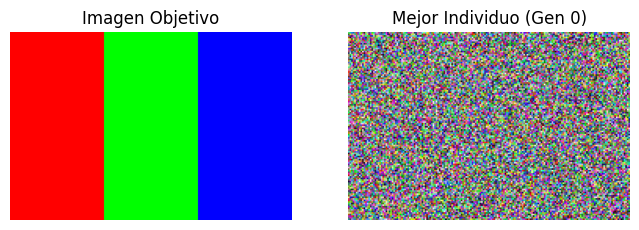

Generación 100 | Mejor Aptitud: -7992918


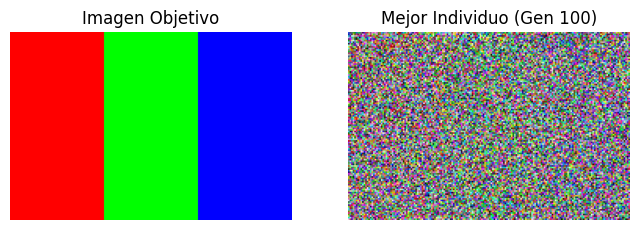

Generación 200 | Mejor Aptitud: -7982173


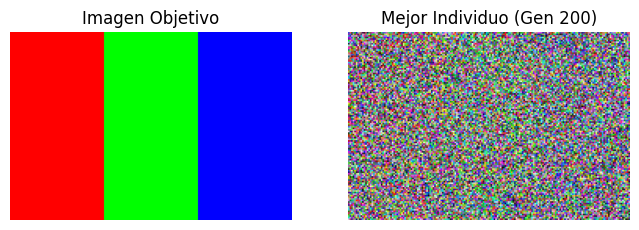

Generación 300 | Mejor Aptitud: -7978790


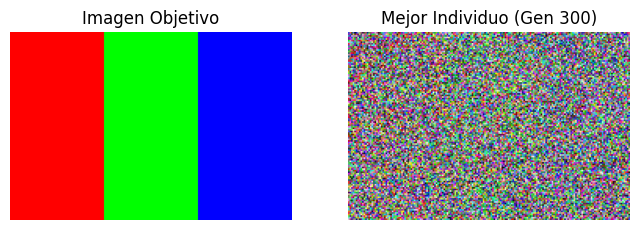

Generación 400 | Mejor Aptitud: -7978316


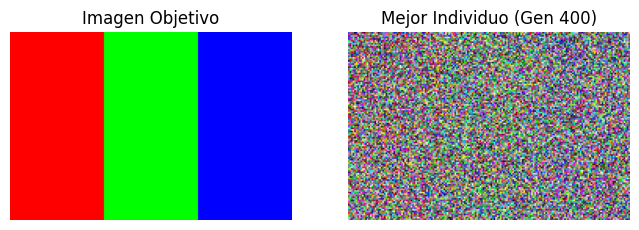

Generación 500 | Mejor Aptitud: -7976177


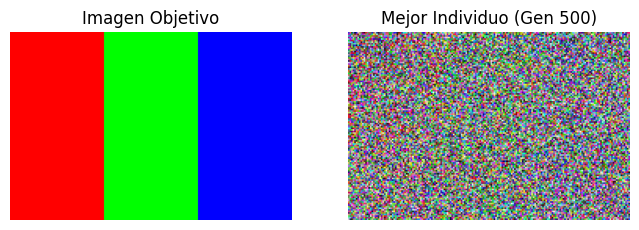

Generación 600 | Mejor Aptitud: -7974978


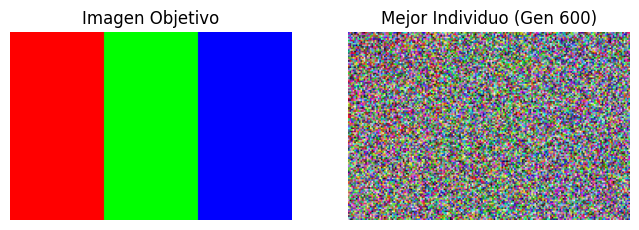

Generación 700 | Mejor Aptitud: -7962886


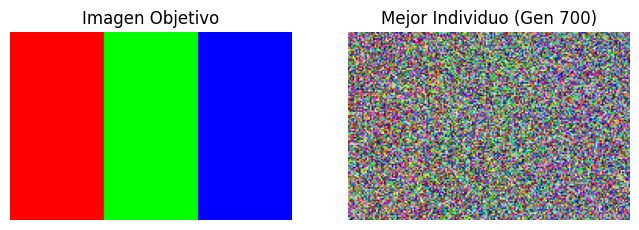

Generación 800 | Mejor Aptitud: -7961558


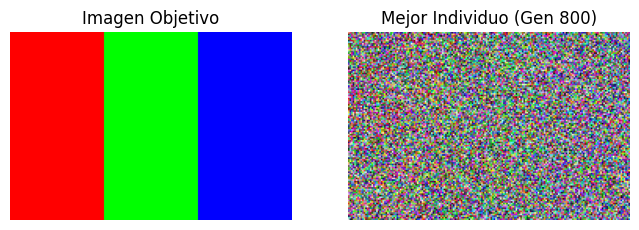

Generación 900 | Mejor Aptitud: -7961037


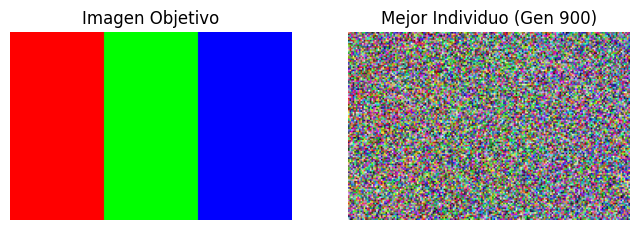

Generación 999 | Mejor Aptitud: -7961037


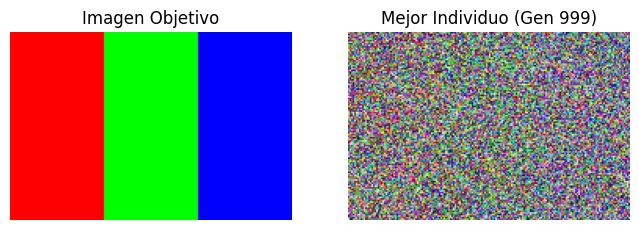

Evolución finalizada.


In [3]:
import numpy as np
import matplotlib.pyplot as plt
import cv2 # Usado para redimensionar imágenes si es necesario

# ==========================================
# 1. DEFINICIÓN DEL PROBLEMA Y PARÁMETROS
# ==========================================
# Basado en los pasos de diseño de un AG: Definir el problema y otros parámetros.
POBLACION_SIZE = 50       # Número K de cromosomas en la población (indicado en el ejercicio)
FILAS = 120               # Alto de la matriz
COLUMNAS = 180            # Ancho de la matriz
CANALES = 3               # Para gráfica RGB (Red, Green, Blue)
GENERACIONES = 1000       # Número M de generaciones (Criterio de parada)
TASA_MUTACION = 0.05      # Probabilidad p_m de mutación. Suele ser baja para no perder buenas soluciones.

# ==========================================
# IMAGEN OBJETIVO (FUNCIÓN DE APTITUD BASE)
# ==========================================
# Para que el código funcione directamente, crearemos una imagen objetivo sintética (una bandera simple).
# En un caso real, puedes cargar tu propia imagen con: target_image = cv2.imread('ruta.jpg')
target_image = np.zeros((FILAS, COLUMNAS, CANALES), dtype=np.uint8)
target_image[:, :60] = [255, 0, 0]      # Franja roja
target_image[:, 60:120] = [0, 255, 0]    # Franja verde
target_image[:, 120:] = [0, 0, 255]      # Franja azul

# ==========================================
# 2. RUTINA GENERA (POBLACIÓN INICIAL)
# ==========================================
def generar_poblacion_inicial(tamano, filas, columnas, canales):
    """
    Genera aleatoriamente la primera población. Se crean K cromosomas.
    Los genes toman valores de 0 a 255 (espacio de búsqueda de la imagen).
    """
    return [np.random.randint(0, 256, (filas, columnas, canales), dtype=np.uint8) for _ in range(tamano)]

# ==========================================
# 3. FUNCIÓN DE APTITUD (EVALUACIÓN)
# ==========================================
def calcular_aptitud(individuo, objetivo):
    """
    Define el problema que se pretende solucionar como una función de aptitud.
    Calcula la diferencia absoluta media entre la imagen objetivo y el individuo.
    Como el AG busca maximizar, retornamos un valor negativo (o el inverso de la diferencia).
    """
    # Diferencia absoluta: abs(f(x))
    diferencia = np.sum(np.abs(objetivo.astype(int) - individuo.astype(int)))
    # Aptitud máxima cuando la diferencia es 0
    return -diferencia

# ==========================================
# 4. OPERADORES GENÉTICOS
# ==========================================
def seleccion(poblacion, aptitudes):
    """
    Proceso de selección darwiniana. Usamos un 'Torneo' para elegir a los mejores padres,
    simulando la versión artificial de selección natural dando mayor probabilidad a los más aptos.
    """
    seleccionados = []
    # Elitismo simple: guardamos al mejor directamente
    mejor_idx = np.argmax(aptitudes)
    seleccionados.append(poblacion[mejor_idx])

    # Seleccionamos el resto mediante torneos aleatorios
    for _ in range(POBLACION_SIZE - 1):
        torneo_indices = np.random.choice(range(POBLACION_SIZE), size=3, replace=False)
        mejor_torneo = torneo_indices[np.argmax([aptitudes[i] for i in torneo_indices])]
        seleccionados.append(poblacion[mejor_torneo])
    return seleccionados

def cruce(padre1, padre2):
    """
    Cruce uniforme: se mezclan al azar los genes (píxeles) de dos cromosomas exitosos.
    Permite combinar información genética validada de los padres.
    """
    # Se genera una matriz binaria aleatoria (moneda al aire) para decidir qué pixel hereda de qué padre
    mascara = np.random.randint(0, 2, (FILAS, COLUMNAS, CANALES)).astype(bool)
    hijo = np.where(mascara, padre1, padre2)
    return hijo

def mutacion(individuo, prob_mutacion):
    """
    Operador genético de segundo orden. Permite explorar otras áreas del espacio de soluciones.
    Cambia el valor de algunos píxeles aleatorios por un nuevo valor entre 0 y 255.
    """
    # Matriz booleana indicando qué píxeles mutan basados en la probabilidad p_m
    mutan = np.random.rand(FILAS, COLUMNAS, CANALES) < prob_mutacion
    # Generamos ruido aleatorio para esos píxeles
    ruido = np.random.randint(0, 256, (FILAS, COLUMNAS, CANALES), dtype=np.uint8)
    individuo[mutan] = ruido[mutan]
    return individuo

# ==========================================
# 5. ALGORITMO GENÉTICO PRINCIPAL
# ==========================================
# Paso 1: Generar población aleatoria inicial
poblacion = generar_poblacion_inicial(POBLACION_SIZE, FILAS, COLUMNAS, CANALES)

# Variables para graficar el progreso
historial_aptitud = []

print("Iniciando evolución...")
for generacion in range(GENERACIONES):
    # Evaluar aptitud de la población actual
    aptitudes = [calcular_aptitud(ind, target_image) for ind in poblacion]

    # Guardar la mejor aptitud para el seguimiento estadístico
    mejor_aptitud_gen = np.max(aptitudes)
    historial_aptitud.append(mejor_aptitud_gen)

    # Imprimir progreso y visualizar cada 100 generaciones
    if generacion % 100 == 0 or generacion == GENERACIONES - 1:
        mejor_individuo = poblacion[np.argmax(aptitudes)]
        print(f"Generación {generacion} | Mejor Aptitud: {mejor_aptitud_gen}")

        # Presentar como gráfica RGB
        plt.figure(figsize=(8, 4))
        plt.subplot(1, 2, 1)
        plt.title("Imagen Objetivo")
        plt.imshow(target_image)
        plt.axis('off')

        plt.subplot(1, 2, 2)
        plt.title(f"Mejor Individuo (Gen {generacion})")
        plt.imshow(mejor_individuo)
        plt.axis('off')
        plt.show()

    # Selección de la nueva población de padres
    padres = seleccion(poblacion, aptitudes)

    # Generar la nueva generación (Cruce y Mutación)
    nueva_poblacion = []
    # Mantenemos el elitismo intacto (el mejor pasa directamente sin cruce ni mutación)
    nueva_poblacion.append(padres[0])

    # Cruzamos el resto
    for i in range(1, POBLACION_SIZE):
        p1 = padres[np.random.randint(0, len(padres))]
        p2 = padres[np.random.randint(0, len(padres))]
        hijo = cruce(p1, p2)
        hijo_mutado = mutacion(hijo, TASA_MUTACION)
        nueva_poblacion.append(hijo_mutado)

    # Reemplazo generacional
    poblacion = nueva_poblacion

print("Evolución finalizada.")